<center>
    <h1>DSM050 Data Visualisation</h1>
    <h3>Hadar Sharon</h3>
    <h3>2026-07-13</h3>
    <h2>Midterm coursework assignment</h2>
    <h3>University of London</h3>
    <h4>April 2026 session, MSc Data Science programme</h4>
</center>

---

# Visualising the Anatomy of Aviation Safety Occurrences  
## Human Factors, Mechanical Failure and Flight-Phase Risk in NTSB Accident Data (1982-2022)

**Approximate word count:** 2,373 words, including headings, captions and references

__Project GitHub Repository:__ https://github.com/hadarsharon/DSM050_Midterm_CW1


## Section 1: Research Context and Problem Definition

### Domain of Interest

Aviation safety research has shifted from a primary focus on technical and structural reliability toward the complex socio-technical interactions among human operators, automation, organisational practices, aircraft systems and environmental conditions.

As mechanical reliability has improved, human factors have become more prominent in accident investigation. However, describing incidents simply as "human error" can obscure systemic weaknesses, unreliable human-machine interfaces and cognitive overload.

This project therefore combines aviation safety science, human factors engineering and visual analytics. It examines how human operational errors and mechanical failures appear across flight phases and operational contexts, while recognising that accidents often emerge from interactions rather than a single isolated cause.

### Literature Contextualisation

This project heavily draws upon established models of accident causation and is grounded in five established perspectives:


1. __Reason's Swiss Cheese Model__ describes accidents as the alignment of active errors and latent organisational conditions rather than a single isolated failure (Reason, 1990). This motivates the classification of events containing both human and mechanical findings.
2. __The Human Factors Analysis and Classification System (HFACS)__, developed by Wiegmann and Shappell (2003), provides a structured methodology for categorizing human errors into specific tiers, such as unsafe acts, preconditions for unsafe acts, and supervisory influences. This taxonomy dictates how categorical incident data will be preprocessed and grouped.
3. __The Automation Paradox__, as highlighted by Sarter, Woods, and Billings (1997), pertains to how advanced flight deck automation has fundamentally altered the nature of pilot errors, counterproductively giving birth to cases where flight crews misinterpret system states during critical and/or high-workload phases.
4. __Situation Awareness Failures__: Endsley's (1995) framework on Situation Awareness (SA) in dynamic systems defines how operators perceive, comprehend, and project system states. In aviation, human errors are frequently traced back to breakdowns in SA -- specifically a failure to correctly interpret changing environments or automated system cues rather than lack of pilot skill. This is particularly relevant during changing weather and high-workload phases.
5. __Threat and Error Management__ (TEM): Helmreich's (2000) TEM framework provides an operational lens for analyzing how safety degrades in real time. It separates external operational challenges (i.e. _Threats_, such as adverse weather or mechanical malfunctions) from the crew's responses (i.e. Errors). This framework is vital for our use case because it shifts the focus from isolated human failure to the dynamic interplay between environmental conditions and crew countermeasures (or lack thereof).

### Research Objectives

The overlying objective of this project is to develop a data-driven visual framework that decouples and analyzes the trends, severity, and shared patterns of human errors versus mechanical failures in the context of aviation incidents. 

The specific research objectives can be stated as such:

- __RO1:__ To structurally categorize and map incident data spanning decades, effectively transforming raw narrative and categorical safety records into a standardized framework allowing for human and systemic failure analysis.
- __RO2:__ To formulate and answer three distinct research questions regarding the temporal evolution of incident causes, the correlation between flight phase and incident severity, and the compounding effects of adverse weather on technical versus human failures.
- __RO3:__ To design an visual dashboard that implements perceptual design principles and translates these complex safety correlations into actionable, intuitive insights to communicate to non-technical stakeholders.

### Target Audience

The insights to be generated by this visual analytics project are tailored for three primary stakeholder groups, for which they can prove beneficial:

- __Aviation Regulators and Safety Investigators (e.g., FAA, NTSB, EASA)__: To help identify hidden-but-systemic safety trends that may justify targeted regulatory updates or changes to airframe certification standards.
- __Airline Operational Safety Officers and Crew Resource Management (CRM) Instructors__: To refine training curriculum mmaterials based on tangible visual evidence (e.g. showing which flight phases and system states present the highest cognitive or operational risk to flight crews).
- __Insurance Underwriters and Risk Strategists__: To objectively evaluate systemic industry risk profiles based on historical empirical data rather than isolated catastrophic events.

## Section 2: Research Questions

#### __RQ1:__ How has the proportional distribution and systemic interplay between human factors and mechanical failures evolved in aviation incidents over the past three decades?

This question draws from Reason's (1997) distinction between latent organizational failures and active operational errors in convergence, while utilizing Wiegmann & Shappell's (2003) taxonomic principles to categorize data. The aviation industry widely acknowledges that technology has mitigated many baseline mechanical risks, shifting the statistical burden towards the human operator. However, analyzing this trend over time allows for a critical evaluation of whether human errors are rising in absolute terms, or if they are simply the inevitable remaining failure points left behind by incredibly complex systems (Sarter et al., 1997).

Understanding this historical trajectory prevents retrospective bias. It empirically demonstrates whether safety policies are effective in mitigating modern systemic vulnerabilities, or if regulatory frameworks remain disproportionately focused on legacy technical failures.

#### __RQ2:__ In what ways do specific flight phases (e.g. approach/landing vs. cruise/taxiing) impact environmental threats to degrade flight crew performance and exacerbate incident severity?

Grounded in Helmreich's (2000) Threat and Error Management (TEM) framework and Endsley's (1995) Situation Awareness (SA) model, this question examines the transition from an external environmental hazard (i.e. a threat) to an internal operational mistake (i.e. an error). High-workload environments, such as the approach and landing phase, challenge the pilot's cognitive bandwidth. By cross-examining meteorological data against different operational phases, this question maps exactly where external threats break down a crew's situational awareness and lead to active system failures.

We wish to establish that incidents rarely stem from a single isolated variable. Pinpointing the exact intersections where environmental stress and operational complexity coincide to amplify risk allows airlines to move away from generic safety warnings and implement precise, targeted operational buffers for high-risk flight phases.

#### __RQ3:__ How do incident severity outcomes (e.g. hull damage and injury rates) differ between traditional mechanical breakdowns and failures originating from human-automation interface anomalies?

This question directly addresses the Automation Paradox laid out by Sarter, Woods, and Billings (1997). When advanced flight deck automation behaves unexpectedly, it creates unintended circumstances. Because these modern system anomalies often lead to cognitive disorientation or misdiagnosed flight states, the resulting operational errors can be far more volatile than a standard mechanical failure (e.g. a predictable engine outage), which crews are rigorously trained to troubleshoot.

As the aviation industry tends toward increasingly autonomous systems, quantifying the actual mortality and severity profiles of automation-related mishaps provides critical empirical feedback for aerospace engineers designing the next generation of human-machine interfaces.

---

## Section 3: Dataset Manipulation - Cleaning and Preprocessing using Python

### Dataset Identification and Structure

This project uses the __National Transportation Safety Board (NTSB) Aviation Accident Database__ supplied in two parts: Pre-2008 dataset and Post-2008 dataset. Data is hosted in my GitHub repository: https://github.com/hadarsharon/DSM050_Midterm_CW1/tree/main/ntsb_data

Both datasets contain event and aircraft tables, but causal and sequence information changed with the introduction of the eADMS system. The 1982-2007 files use `Occurrences.csv.gz` and `seq_of_events.csv.gz` whereas the 2008–Present files use `Events_Sequence.csv.gz` and `Findings.csv.gz`. 

This dataset contains civil aviation accident and selected incident records from 1982 to present time (2022), capturing highly granular spatial, temporal, environmental, and operational variables. While 2023–2026 records exist in the dataset, they are excluded as recent investigations have substantially lower completeness rate and 2026 is a partial year.

The data folders are expected beside this notebook. The official NTSB CSV dump contains non-ASCII characters, which will crash a default Python data import - we handle this using `encoding='latin1'`.

#### Event Backbone and Identifier Validation

In [1]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "hadarsharon/DSM050_Midterm_CW1/main/ntsb_data"
)

PRE_DIR = f"{BASE_URL}/pre2008"
POST_DIR = f"{BASE_URL}/post2008"

START_YEAR, END_YEAR = 1982, 2022

# Helper function to read different files in the dataset
def read_ntsb(folder, filename, usecols=None):
    url = f"{folder}/{filename}"
    return pd.read_csv(
        url,
        compression="gzip",
        encoding="latin1",
        low_memory=False,
        usecols=usecols,
    )

Only fields required by the research questions are loaded. Raw `ev_id` values are unique within each schema, but one identifier is reused across the two folders. Prefixing the schema creates a globally unique key. Dates are parsed explicitly, and the recorded year is checked against the parsed value.

In [2]:
event_cols = [
    "ev_id", "ev_type", "ev_date", "ev_year", "wx_cond_basic",
    "ev_highest_injury", "inj_tot_f", "inj_tot_s", "inj_tot_m", "inj_tot_n",
]

pre_events = read_ntsb(PRE_DIR, "events.csv.gz", event_cols)
post_events = read_ntsb(POST_DIR, "events.csv.gz", event_cols)

# Limit years
pre_events = pre_events.query("@START_YEAR <= ev_year <= @END_YEAR")
post_events = post_events.query("@START_YEAR <= ev_year <= @END_YEAR")

In [3]:
# Verify `ev_id` is a valid UUID
assert pre_events["ev_id"].is_unique
assert post_events["ev_id"].is_unique

In [4]:
pre_events = pre_events.assign(
    event_id="legacy:" + pre_events["ev_id"].astype("string"),
    schema_era="Legacy (1982–2007)",
)
post_events = post_events.assign(
    event_id="eadms:" + post_events["ev_id"].astype("string"),
    schema_era="eADMS (2008–2022)",
)

In [5]:
# Merge the datasets into one dataframe and ensure no overlaps

events_df = pd.concat([pre_events, post_events], ignore_index=True)
assert events_df["event_id"].is_unique

In [6]:
display(
    events_df.groupby("schema_era")
    .agg(events=("event_id", "size"), first_year=("ev_year", "min"), last_year=("ev_year", "max"))
    .style.format({"events": "{:,}"})
)

,events,first_year,last_year
schema_era,,,
Legacy (1982–2007),"62,995",1982,2007
eADMS (2008–2022),"25,151",2008,2022


In [7]:
# Examine datatypes in high level

events_df.dtypes

ev_id                        object
ev_type                      object
ev_date                      object
ev_year                       int64
ev_highest_injury            object
inj_tot_f                     int64
inj_tot_m                     int64
inj_tot_n                     int64
inj_tot_s                     int64
wx_cond_basic                object
event_id             string[python]
schema_era                   object
dtype: object

In [8]:
# Cast date explicitly (it's loaded as object)
events_df["event_date"] = pd.to_datetime(events_df["ev_date"], format="%m/%d/%y %H:%M:%S", errors="coerce")

#### Aircraft Damage and Operational Phase data

An event may involve several aircraft. Maximum aircraft damage is therefore reduced to one ordered event-level value:
> Unknown < Minor < Substantial < Destroyed

Flight-phase codes cannot be shared directly across schemas. Legacy codes are decoded through `ct_seqevt.csv.gz` and eADMS phase descriptions come from its data dictionary. A small, visible set of text rules then harmonises the official descriptions into broad phases. The defining eADMS sequence item is prioritised - when unavailable, the earliest recorded occurrence is used. This preserves one phase per event while acknowledging that a complete occurrence may contain several stages.

In [9]:
aircraft_cols = ["ev_id", "Aircraft_Key", "damage"]

pre_aircraft = read_ntsb(PRE_DIR, "aircraft.csv.gz", aircraft_cols)
post_aircraft = read_ntsb(POST_DIR, "aircraft.csv.gz", aircraft_cols)

pre_aircraft["event_id"] = "legacy:" + pre_aircraft["ev_id"].astype("string")
post_aircraft["event_id"] = "eadms:" + post_aircraft["ev_id"].astype("string")

In [10]:
# Unify pre & post aircraft datasets
aircraft_df = pd.concat([pre_aircraft, post_aircraft], ignore_index=True)

# Join aircraft data on events data (using event_id as key)
aircraft_df = aircraft_df[aircraft_df["event_id"].isin(events_df["event_id"])]

In [11]:
# Ensure no duplicates in joined data (as result of join, keys)
assert not aircraft_df.duplicated(["event_id", "Aircraft_Key"]).any()

In [12]:
# Phase codes are decoded from the files supplied with each schema.
legacy_lookup = read_ntsb(PRE_DIR, "ct_seqevt.csv.gz", ["code", "meaning"])

legacy_lookup["code"] = pd.to_numeric(legacy_lookup["code"], errors="coerce")
legacy_lookup = legacy_lookup.dropna(subset=["code"]).drop_duplicates("code")

pre_phase_lookup = legacy_lookup.rename(
    columns={"code": "phase_code", "meaning": "phase_description"}
).assign(schema="legacy")[["schema", "phase_code", "phase_description"]]

In [13]:
post_dictionary = read_ntsb(POST_DIR, "eADMSPUB_DataDictionary.csv.gz")

post_phase_lookup = post_dictionary[
    post_dictionary["Table"].eq("Events_Sequence")
    & post_dictionary["Column"].eq("Occurrence_Code")
    & post_dictionary["code_iaids"].astype("string").str.fullmatch(r"\d{3}xxx", na=False)
][["code_iaids", "meaning"]]

In [14]:
post_phase_lookup["phase_code"] = post_phase_lookup["code_iaids"].str[:3].astype(int)
post_phase_lookup = post_phase_lookup.rename(
    columns={"meaning": "phase_description"}
).assign(schema="eadms")[["schema", "phase_code", "phase_description"]]

# Construct shared lookup
phase_lookup = pd.concat([pre_phase_lookup, post_phase_lookup], ignore_index=True)

For operational phase, the pre/post data diverges: pre-2008 uses `Occurrences` whereas since-2008 uses `Events_Sequence`:

In [15]:
pre_sequence = read_ntsb(
    PRE_DIR, "Occurrences.csv.gz",
    ["ev_id", "Aircraft_Key", "Occurrence_No", "Phase_of_Flight"],
).rename(columns={"Phase_of_Flight": "phase_code"})

pre_sequence = pre_sequence.assign(schema="legacy", is_defining=False)

post_sequence = read_ntsb(
    POST_DIR, "Events_Sequence.csv.gz",
    ["ev_id", "Aircraft_Key", "Occurrence_No", "phase_no", "Defining_ev"],
).rename(columns={"phase_no": "phase_code"})

post_sequence = post_sequence.assign(
    schema="eadms",
    is_defining=post_sequence["Defining_ev"].eq(1),
)

In [16]:
# Join pre/post sequence/occurrences data
sequences_df = pd.concat([pre_sequence, post_sequence], ignore_index=True)

In [17]:
sequences_df["phase_code"] = pd.to_numeric(sequences_df["phase_code"], errors="coerce")
sequences_df["event_id"] = sequences_df["schema"] + ":" + sequences_df["ev_id"].astype("string")
sequences_df = sequences_df[sequences_df["event_id"].isin(events_df["event_id"])].merge(
    phase_lookup,
    on=["schema", "phase_code"],
    how="left",
    validate="many_to_one",
)

#### Causal Taxonomy data

The two findings systems are reduced to the same three reproducible event flags. A **human finding** follows the official personnel category. A **mechanical failure** requires an official technical category and explicit `failure` or `malfunction` wording. A **human-automation finding** uses only the legacy human-performance subject `AUTOPILOT` or the eADMS personnel finding `Use of automation`.

Legacy rows are restricted to NTSB cause or factor designations; eADMS rows are restricted to findings included in the probable-cause record. These definitions intentionally favour precision over recall. They do not claim to reproduce HFACS in full, and indirect monitoring, mode-awareness or degradation cases may be omitted.

In [18]:
# Decode the legacy finding labels supplied by the NTSB lookup table
lookup = legacy_lookup.set_index("code")["meaning"]

In [19]:
pre_findings = read_ntsb(
    PRE_DIR, "seq_of_events.csv.gz",
    ["ev_id", "group_code", "Subj_Code", "Modifier_Code", "Cause_Factor"],
)

pre_findings = pre_findings[pre_findings["Cause_Factor"].fillna("").astype("string").str.strip().str.upper().isin(["C", "F"])]
pre_findings["event_id"] = "legacy:" + pre_findings["ev_id"].astype("string")
pre_findings["subject"] = pd.to_numeric(pre_findings["Subj_Code"], errors="coerce").map(lookup)
pre_findings["modifier"] = pd.to_numeric(pre_findings["Modifier_Code"], errors="coerce").map(lookup)

In [20]:
pre_findings["human_flag"] = pre_findings["group_code"].eq(2)
pre_findings["mechanical_flag"] = (
    pre_findings["group_code"].eq(1)
    & pre_findings["modifier"].str.contains(r"failure|malfunction", case=False, na=False)
)
pre_findings["automation_flag"] = pre_findings["group_code"].eq(2) & pre_findings["subject"].eq("AUTOPILOT")

In [21]:
post_findings = read_ntsb(
    POST_DIR, "Findings.csv.gz",
    ["ev_id", "finding_description", "category_no", "cm_inPc"],
)
post_findings = post_findings[post_findings["cm_inPc"].fillna("").astype("string").str.strip().str.upper().eq("T")]
post_findings["event_id"] = "eadms:" + post_findings["ev_id"].astype("string")
post_findings["finding_description"] = post_findings["finding_description"].fillna("").astype("string").str.strip()

In [22]:
post_findings["human_flag"] = post_findings["category_no"].eq(2)
post_findings["mechanical_flag"] = (
    post_findings["category_no"].eq(1)
    & post_findings["finding_description"].str.contains(r"failure|malfunction", case=False, na=False)
)
post_findings["automation_flag"] = (
    post_findings["category_no"].eq(2)
    & post_findings["finding_description"].str.contains("Use of automation", case=False, regex=False, na=False)
)

In [23]:
flags = ["human_flag", "mechanical_flag", "automation_flag"]
causal_flags_df = (
    pd.concat([pre_findings[["event_id", *flags]], post_findings[["event_id", *flags]]])
    .query("event_id in @events_df.event_id")
    .groupby("event_id", as_index=False)[flags]
    .any()
)

event_flag_counts = pd.DataFrame({
    "Event flag": ["Human", "Mechanical failure", "Human–automation interface"],
    "Events": [causal_flags_df[column].sum() for column in flags],
})
display(event_flag_counts.style.format({"Events": "{:,}"}).hide(axis="index"))

Event flag,Events
Human,"70,277"
Mechanical failure,"6,469"
Human–automation interface,39


In [24]:
taxonomy_examples = pd.concat([
    pre_findings.loc[
        pre_findings["mechanical_flag"] | pre_findings["automation_flag"],
        ["subject", "modifier"],
    ].drop_duplicates().head(4).assign(schema="Legacy"),
    post_findings.loc[
        post_findings["mechanical_flag"] | post_findings["automation_flag"],
        ["finding_description"],
    ].drop_duplicates().head(4).assign(schema="eADMS"),
], ignore_index=True)

display(taxonomy_examples.fillna(""))

,subject,modifier,schema,finding_description
0,"ENGINE ASSEMBLY,PUSH ROD","FAILURE,TOTAL",Legacy,
1,"IGNITION SYSTEM,MAGNETO","FAILURE,PARTIAL",Legacy,
2,"LANDING GEAR,STEERING SYSTEM","FAILURE,TOTAL",Legacy,
3,POWERPLANT,"FAILURE,TOTAL",Legacy,
4,,,eADMS,Aircraft-Aircraft power plant-Engine (reciproc...
5,,,eADMS,Aircraft-Aircraft systems-Landing gear system-...
6,,,eADMS,Aircraft-Aircraft systems-Vacuum system-Vacuum...
7,,,eADMS,Aircraft-Aircraft systems-Flight control syste...


### Handling Missing Values

Official injury totals are complete and are not imputed. Missing weather, injury-severity, phase and damage categories are retained as `Unknown`, making data absence visible. `total_injured` combines fatal, serious and minor counts.

Each one-to-many table has now been reduced to one event-level row. The final joins therefore use one-to-one validation, preventing repeated injuries or duplicated event counts. A coverage table reports how many events have known weather, phase, damage and a classified causal profile. This is important because a low missing rate in the event table does not guarantee equivalent coverage after sequence or findings tables are joined. The analysis keeps unclassified cases in the master dataset but excludes them only from visualisations that require a causal group. This preserves the full occurrence population while making each chart’s analytical denominator explicit.

In [25]:
weather_labels = {"Unk": "Unknown", "": "Unknown"}
severity_labels = {
    "FATL": "Fatal", "SERS": "Serious",
    "MINR": "Minor", "NONE": "None", "": "Unknown",
}

In [26]:
events_df["weather_condition"] = (
    events_df["wx_cond_basic"].fillna("").astype("string").str.strip()
    .replace(weather_labels)
)

In [27]:
events_df["injury_severity"] = (
    events_df["ev_highest_injury"].fillna("").astype("string").str.strip()
    .replace(severity_labels)
)

In [28]:
aircraft_df["damage_clean"] = aircraft_df["damage"].fillna("").astype("string").str.strip().replace(
    {"DEST": "Destroyed", "SUBS": "Substantial", "MINR": "Minor", "UNK": "Unknown", "": "Unknown"}
)

damage_rank = {"Unknown": 0, "Minor": 1, "Substantial": 2, "Destroyed": 3}
aircraft_df["damage_rank"] = aircraft_df["damage_clean"].map(damage_rank).fillna(0)

In [29]:
# Merge event and aircraft damage mapping
event_damage_df = (
    aircraft_df.sort_values(["event_id", "damage_rank"])
    .groupby("event_id", as_index=False)
    .tail(1)[["event_id", "damage_clean"]]
    .rename(columns={"damage_clean": "aircraft_damage"})
)

### Preparing the data to support effective visualisation

In [30]:
PHASE_RULES = {
    "Landing": r"landing",
    "Descent": r"descent",
    "Approach": r"approach|go-around|circling",
    "Takeoff": r"takeoff",
    "Climb": r"climb",
    "Cruise": r"cruise|enroute|holding",
    "Maneuvering": r"maneuvering",
    "Hover": r"hover",
    "Taxi": r"taxi|pushback|tow",
    "Standing": r"standing|prior to flight",
    "Other": r"other|post-impact",
}

sequences_df["broad_phase"] = "Unknown"
for phase, pattern in PHASE_RULES.items():
    mask = sequences_df["broad_phase"].eq("Unknown") & sequences_df["phase_description"].str.contains(
        pattern, case=False, regex=True, na=False
    )
    sequences_df.loc[mask, "broad_phase"] = phase

sequences_df["priority"] = np.where(sequences_df["is_defining"], 0, 1)
event_phase_df = (
    sequences_df.sort_values(["event_id", "priority", "Aircraft_Key", "Occurrence_No"])
    .drop_duplicates("event_id")[["event_id", "broad_phase"]]
)

phase_audit = (
    sequences_df[["schema", "phase_code", "phase_description", "broad_phase"]]
    .drop_duplicates()
    .sort_values(["schema", "phase_code"])
)
display(phase_audit.groupby("schema", group_keys=False).head(6))

,schema,phase_code,phase_description,broad_phase
138090,eadms,100,Prior to Flight,Standing
139029,eadms,150,Standing,Standing
141854,eadms,151,Standing-Engine(s) Not Oper,Standing
138337,eadms,152,Standing-Engine(s) Start-up,Standing
137983,eadms,153,Standing-Engine(s) Operating,Standing
141481,eadms,154,Standing-Engine(s) Shutdown,Standing
955,legacy,0,NaN,Unknown
26085,legacy,310,ON GROUND/WATER COLLISION WITH OBJECT,Unknown
25176,legacy,340,OVERRUN,Unknown
133,legacy,500,STANDING,Standing


In [31]:
events_df["total_injured"] = events_df[["inj_tot_f", "inj_tot_s", "inj_tot_m"]].sum(axis=1)
events_df["log_total_injured"] = np.log1p(events_df["total_injured"])
events_df["severe_outcome"] = events_df["injury_severity"].isin(["Fatal", "Serious"])

The event backbone is joined only to event-level aggregates, preventing multiplication by multiple aircraft, occurrences or findings. A severe outcome is defined as an event whose highest reported injury is serious or fatal. `log1p(total_injured)` is used only to visualise the highly right-skewed numerical distribution - it is not described as a risk score.

In [32]:
analysis_df = (
    events_df
    .merge(event_damage_df, on="event_id", how="left", validate="one_to_one")
    .merge(event_phase_df, on="event_id", how="left", validate="one_to_one")
    .merge(causal_flags_df, on="event_id", how="left", validate="one_to_one")
)

In [33]:
analysis_df.head(5)

,ev_id,ev_type,ev_date,ev_year,ev_highest_injury,inj_tot_f,inj_tot_m,inj_tot_n,inj_tot_s,wx_cond_basic,...,weather_condition,injury_severity,total_injured,log_total_injured,severe_outcome,aircraft_damage,broad_phase,human_flag,mechanical_flag,automation_flag
0,20001213X25852,ACC,06/11/88 00:00:00,1988,FATL,1,0,0,0,Unk,...,Unknown,Fatal,1,0.693147,True,Destroyed,Unknown,True,False,False
1,20001211X15972,ACC,11/06/92 00:00:00,1992,FATL,2,0,0,0,IMC,...,IMC,Fatal,2,1.098612,True,Destroyed,Cruise,True,False,False
2,20001211X15973,ACC,11/08/92 00:00:00,1992,FATL,3,0,0,0,IMC,...,IMC,Fatal,3,1.386294,True,Destroyed,Cruise,True,False,False
3,20001211X11897,ACC,03/20/93 00:00:00,1993,FATL,1,0,0,0,IMC,...,IMC,Fatal,1,0.693147,True,Substantial,Maneuvering,True,False,False
4,20001211X12053,ACC,04/03/93 00:00:00,1993,FATL,2,0,0,0,IMC,...,IMC,Fatal,2,1.098612,True,Destroyed,Cruise,True,False,False


In [34]:
flags = ["human_flag", "mechanical_flag", "automation_flag"]
analysis_df[flags] = analysis_df[flags].astype("boolean").fillna(False).astype(bool)
analysis_df[["aircraft_damage", "broad_phase"]] = analysis_df[
    ["aircraft_damage", "broad_phase"]
].fillna("Unknown")

In [35]:
analysis_df["causal_profile"] = np.select(
    [
        analysis_df["human_flag"] & analysis_df["mechanical_flag"],
        analysis_df["human_flag"],
        analysis_df["mechanical_flag"],
    ],
    ["Human + mechanical", "Human only", "Mechanical only"],
    default="Other / unclassified",
)

In [36]:
analysis_df["rq3_group"] = np.select(
    [
        analysis_df["automation_flag"],
        analysis_df["mechanical_flag"] & ~analysis_df["human_flag"],
    ],
    ["Human–automation interface", "Traditional mechanical"],
    default="Other",
)

In [37]:
# Summarize what we covered in a df of its own and print it
coverage = pd.DataFrame({
    "Metric": ["Events", "Known weather", "Known phase", "Known damage", "Classified causes"],
    "Count": [
        len(analysis_df),
        analysis_df["weather_condition"].ne("Unknown").sum(),
        analysis_df["broad_phase"].ne("Unknown").sum(),
        analysis_df["aircraft_damage"].ne("Unknown").sum(),
        analysis_df["causal_profile"].ne("Other / unclassified").sum(),
    ],
})
coverage["Percent"] = coverage["Count"] / len(analysis_df) * 100

display(coverage.style.format({"Count": "{:,}", "Percent": "{:.1f}%"}).hide(axis="index"))
print(f"Coverage: {analysis_df['ev_year'].min()}–{analysis_df['ev_year'].max()}")
print(f"Unique events: {len(analysis_df):,}")

Metric,Count,Percent
Events,"88,146",100.0%
Known weather,"82,794",93.9%
Known phase,"84,120",95.4%
Known damage,"84,876",96.3%
Classified causes,"73,740",83.7%


Coverage: 1982–2022
Unique events: 88,146


---

### Section 4: Exploratroy Data Analysis (EDA) & Visualisation

### Dataset characteristics and univariate analysis

The univariate figures cover a nominal variable (__broad flight phase__), an ordinal variable (__highest injury severity__) and a numerical variable (__total injured persons__). Unknown categories remain visible. Counts are accompanied by percentages where useful so that the figures communicate both scale and composition. Phase is used as operational context in RQ2, injury severity becomes the principal outcome for RQ2 and RQ3, and the numerical injury total shows whether a small number of high-casualty events dominate the distribution. Weather condition and maximum aircraft damage are introduced in the multivariate figures where their comparisons are directly relevant to the research questions.

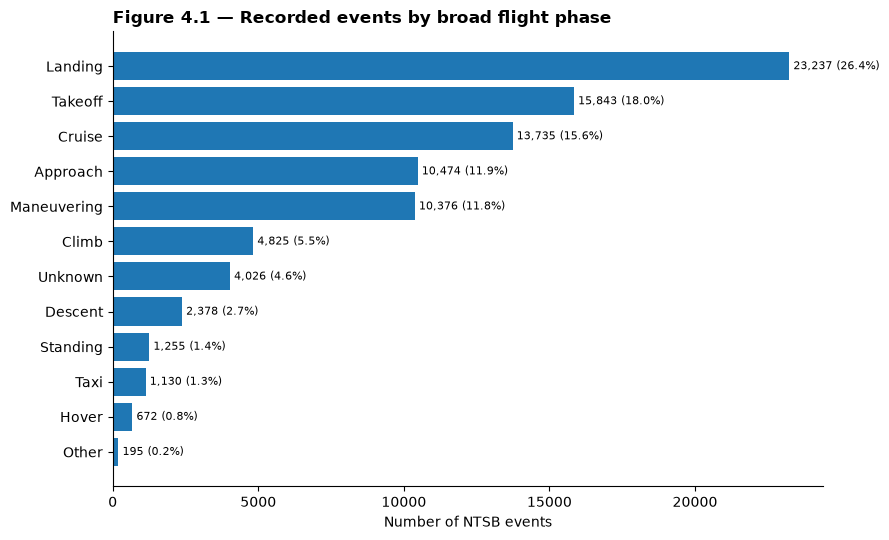

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

phase_counts = analysis_df["broad_phase"].value_counts().sort_values()
phase_percent = phase_counts / len(analysis_df) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(phase_counts.index, phase_counts.values)
ax.set_title("Figure 4.1 — Recorded events by broad flight phase", loc="left", weight="bold")
ax.set_xlabel("Number of NTSB events")
ax.set_ylabel("")
ax.bar_label(
    bars,
    labels=[f"{count:,} ({pct:.1f}%)" for count, pct in zip(phase_counts, phase_percent)],
    padding=3,
    fontsize=8,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

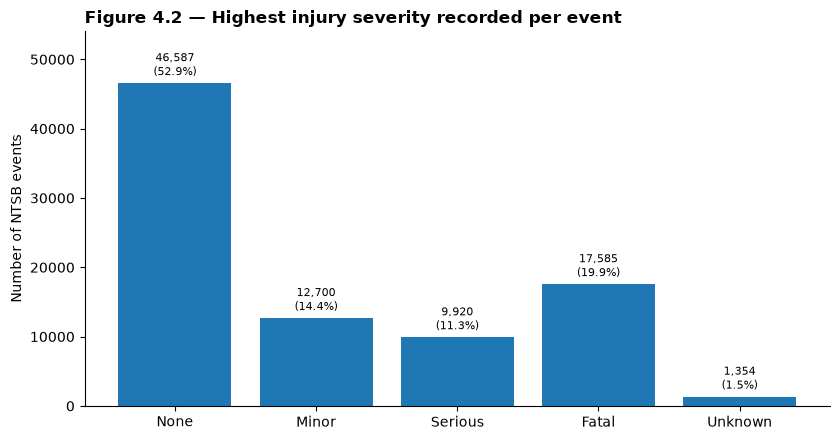

In [39]:
severity_order = ["None", "Minor", "Serious", "Fatal", "Unknown"]
severity_counts = analysis_df["injury_severity"].value_counts().reindex(
    severity_order, fill_value=0
)
severity_percent = severity_counts / len(analysis_df) * 100

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(severity_counts.index, severity_counts.values)
ax.set_title("Figure 4.2 — Highest injury severity recorded per event", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Number of NTSB events")
ax.set_ylim(0, severity_counts.max() * 1.16)
ax.bar_label(
    bars,
    labels=[f"{count:,}\n({pct:.1f}%)" for count, pct in zip(severity_counts, severity_percent)],
    padding=3,
    fontsize=8,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

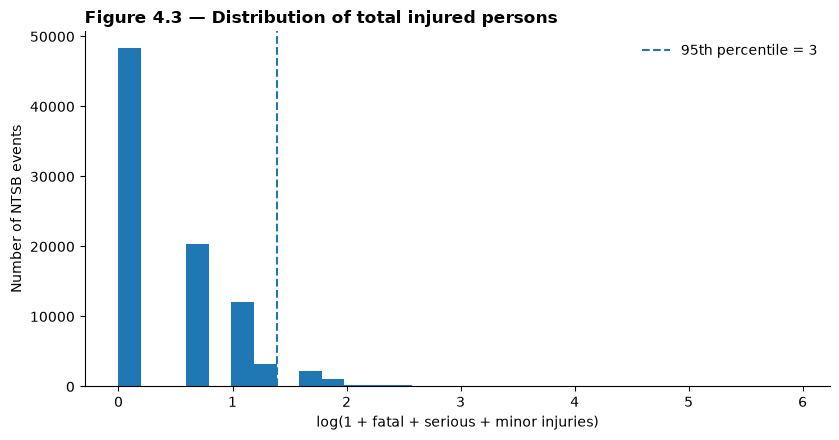

,Total injured
count,88146.000000
mean,1.080957
std,5.743280
min,0.000000
50%,0.000000
75%,1.000000
90%,2.000000
95%,3.000000
99%,7.000000
max,380.000000


In [40]:
p95 = analysis_df["total_injured"].quantile(0.95)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(analysis_df["log_total_injured"], bins=30)
ax.axvline(np.log1p(p95), linestyle="--", linewidth=1.5, label=f"95th percentile = {p95:.0f}")
ax.set_title("Figure 4.3 — Distribution of total injured persons", loc="left", weight="bold")
ax.set_xlabel("log(1 + fatal + serious + minor injuries)")
ax.set_ylabel("Number of NTSB events")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

display(
    analysis_df["total_injured"]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame("Total injured")
)

Landing and take-off contain the largest numbers of recorded events, while the injury distribution is strongly concentrated at zero or one injured person. A small number of high-capacity accidents create a long right tail, so the logarithmic display makes the majority visible without discarding extreme cases. These are occurrence counts, not phase-specific accident rates, because exposure measures such as departures or flight hours are unavailable.

### Multivariate analysis

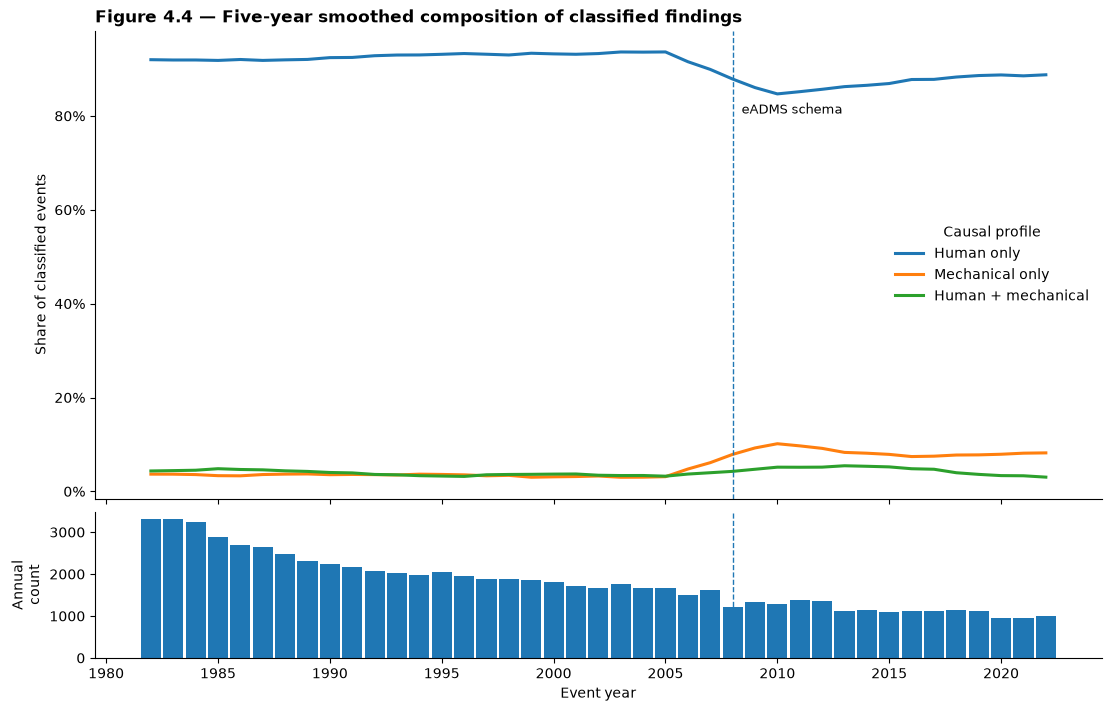

In [41]:
from matplotlib.ticker import PercentFormatter

profile_order = ["Human only", "Mechanical only", "Human + mechanical"]

rq1 = analysis_df[analysis_df["causal_profile"].isin(profile_order)]
rq1_share = (
    pd.crosstab(rq1["ev_year"], rq1["causal_profile"], normalize="index")
    .reindex(columns=profile_order, fill_value=0)
    .mul(100)
)
rq1_smooth = rq1_share.rolling(5, center=True, min_periods=3).mean()
rq1_counts = rq1.groupby("ev_year").size().reindex(rq1_share.index, fill_value=0)

fig, (ax, ax_count) = plt.subplots(
    2, 1,
    figsize=(11, 7),
    sharex=True,
    layout="constrained",
    gridspec_kw={"height_ratios": [3.2, 1]},
)

for profile in profile_order:
    ax.plot(rq1_smooth.index, rq1_smooth[profile], linewidth=2.2, label=profile)

ax.axvline(2008, linestyle="--", linewidth=1)
ax.text(2008.4, ax.get_ylim()[1] * 0.82, "eADMS schema", fontsize=9)
ax.set_title(
    "Figure 4.4 — Five-year smoothed composition of classified findings",
    loc="left",
    weight="bold",
)
ax.set_ylabel("Share of classified events")
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(title="Causal profile", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

ax_count.bar(rq1_counts.index, rq1_counts.values, width=0.9)
ax_count.axvline(2008, linestyle="--", linewidth=1)
ax_count.set_xlabel("Event year")
ax_count.set_ylabel("Annual\ncount")
ax_count.spines[["top", "right"]].set_visible(False)

plt.show()

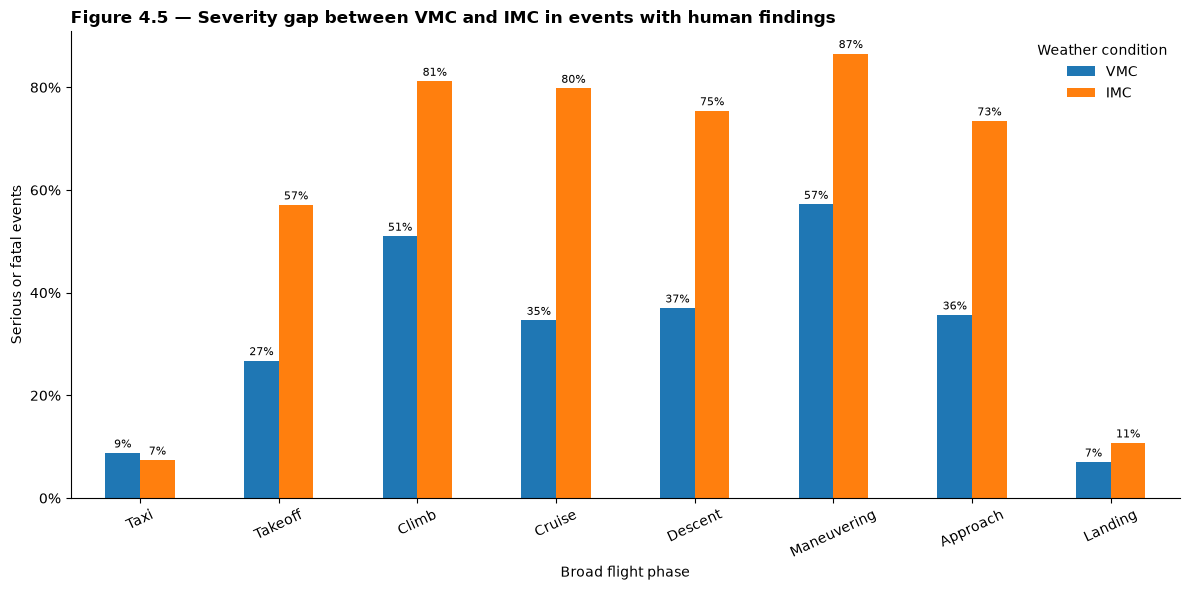

In [42]:
phase_order = [
    "Taxi", "Takeoff", "Climb", "Cruise",
    "Descent", "Maneuvering", "Approach", "Landing",
]

rq2 = analysis_df[
    analysis_df["human_flag"]
    & analysis_df["weather_condition"].isin(["VMC", "IMC"])
    & analysis_df["broad_phase"].isin(phase_order)
]

rq2_plot = (
    rq2.groupby(["broad_phase", "weather_condition"])["severe_outcome"]
    .mean().mul(100)
    .unstack()
    .reindex(phase_order)[["VMC", "IMC"]]
)

fig, ax = plt.subplots(figsize=(12, 6))
rq2_plot.plot.bar(ax=ax)
ax.set_title(
    "Figure 4.5 — Severity gap between VMC and IMC in events with human findings",
    loc="left", weight="bold",
)
ax.set_xlabel("Broad flight phase")
ax.set_ylabel("Serious or fatal events")
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Weather condition", frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", padding=2, fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

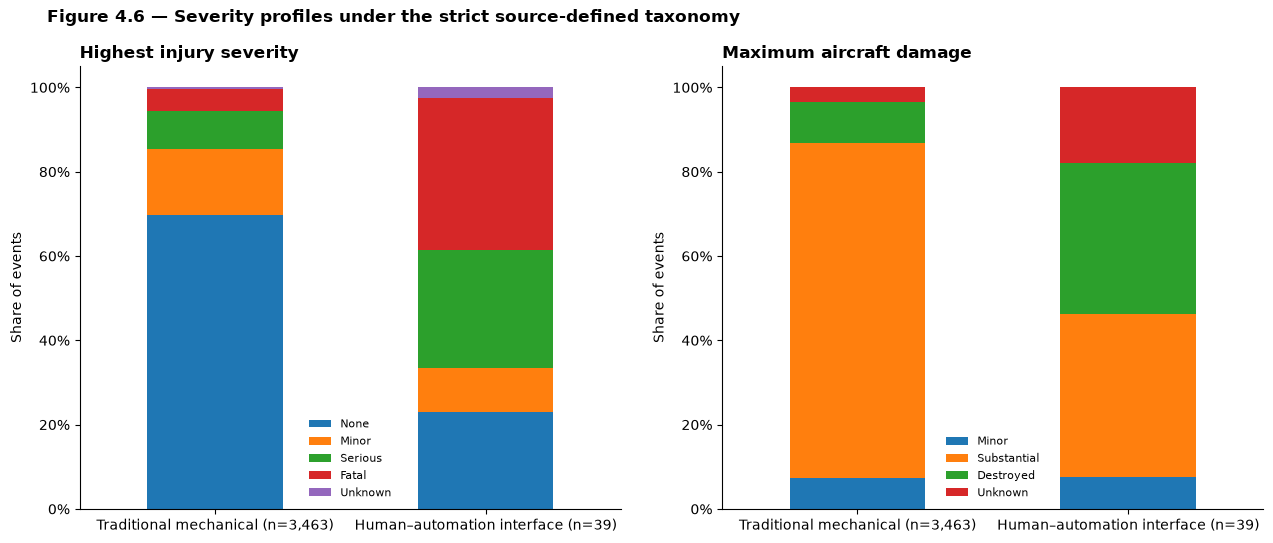

In [43]:
groups = ["Traditional mechanical", "Human–automation interface"]

rq3 = analysis_df[analysis_df["rq3_group"].isin(groups)]
labels = {
    group: f"{group} (n={(rq3['rq3_group'] == group).sum():,})"
    for group in groups
}

injury_share = pd.crosstab(
    rq3["rq3_group"], rq3["injury_severity"], normalize="index"
).reindex(index=groups, columns=["None", "Minor", "Serious", "Fatal", "Unknown"], fill_value=0)

damage_share = pd.crosstab(
    rq3["rq3_group"], rq3["aircraft_damage"], normalize="index"
).reindex(index=groups, columns=["Minor", "Substantial", "Destroyed", "Unknown"], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
injury_share.rename(index=labels).plot.bar(stacked=True, ax=axes[0])
damage_share.rename(index=labels).plot.bar(stacked=True, ax=axes[1])

for ax, title in zip(axes, ["Highest injury severity", "Maximum aircraft damage"]):
    ax.set_title(title, loc="left", weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Share of events")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="", frameon=False, fontsize=8)
    sns.despine(ax=ax)

fig.suptitle(
    "Figure 4.6 — Severity profiles under the strict source-defined taxonomy",
    x=0.04, ha="left", weight="bold",
)
plt.tight_layout()
plt.show()

## Section 5 — Interpretation and Discussion of Findings

### RQ1: temporal distribution and interplay

Human-only findings dominate the classified composition throughout the study period. Before 2008 they generally account for more than 90% of classified events - however after the eADMS transition their share is lower, while mechanical-only and combined findings become more visible. The result does __not__ mean that independent human error caused almost every occurrence. NTSB findings describe actions and conditions within investigations, and the strict mechanical rule counts only technical findings explicitly labelled as failures or malfunctions.

The visible break near 2008 should therefore be read partly as a schema effect. The persistence of human, mechanical and combined profiles __nevertheless supports Reason's systems view__: regulators and investigators should retain both technical and operational branches rather than searching for a single dominant cause.

### RQ2: phase, weather and human performance findings

IMC is associated with a higher serious-or-fatal proportion in most airborne phases containing human findings. The largest contrasts occur in cruise, approach and descent, while climb and manoeuvring are severe under both weather categories. Taxi and landing show much lower proportions. The figure also reports group sizes, revealing that some IMC estimates—especially taxi—are based on comparatively few events.

These patterns are __consistent with TEM and Situation Awareness theory:__ environmental difficulty appears most consequential where crews must diagnose, configure or control the aircraft with constrained information and recovery time. They do ___not___ establish that IMC caused the outcome, because aircraft type, terrain, operation and event selection may differ between groups. For safety managers, the results support targeted instrument-monitoring, threat-briefing and CRM scenarios for airborne transitions rather than identical warnings for every phase.

### RQ3: automation interface anomalies and mechanical breakdowns

The strict taxonomy identifies 39 explicit human-automation events and 3,463 traditional mechanical events. Approximately 64% of the automation group has a serious-or-fatal highest injury classification, compared with about 14% of the traditional mechanical group. Destroyed aircraft occur in roughly 36% and 10% of the groups respectively.

The contrast is large but exploratory. The automation category includes only legacy human-performance `AUTOPILOT` findings and modern personnel `Use of automation` findings; it omits less explicit mode-awareness, monitoring and interface-design cases. The comparison therefore __supports the plausibility of the Automation Paradox__ rather than estimating a general automation risk rate. Its practical value lies in identifying a small, severe case set for qualitative review, interface design and automation-specific training.

### Implications and limitations

The combined evidence favours a socio-technical account of aviation safety. Human findings are numerically dominant, but mechanical conditions and weather remain important, and the clearest patterns emerge from context and interaction. Safety managers can prioritise phase-specific scenarios, investigators can preserve both human and technical causal branches, and designers can treat explicit automation events as high-value cases.

Several limitations constrain generalisation. The database contains investigated occurrences rather than exposure denominators, so no chart measures accident probability per flight or phase. The 2008 schema transition introduces classification discontinuity. Selecting one primary phase and one maximum damage state simplifies multi-stage and multi-aircraft events. Unknown categories remain visible rather than being imputed. Finally, the strict taxonomy improves reproducibility at the cost of recall. These restrictions make the analysis descriptive, but they prevent unsupported causal claims and keep each visualisation tied to recorded NTSB evidence.

---

### References

* Endsley, M. R. (1995). Toward a theory of situation awareness in dynamic systems. *Human Factors, 37*(1), 32–64. https://doi.org/10.1518/001872095779049543
* Helmreich, R. L. (2000). On error management: Lessons from aviation. *BMJ, 320*(7237), 781–785. https://doi.org/10.1136/bmj.320.7237.781
* Munzner, T. (2014). *Visualization analysis and design*. A K Peters/CRC Press.
* National Transportation Safety Board. (n.d.-a). *Aviation accident data*. Retrieved July 13, 2026.
* National Transportation Safety Board. (n.d.-b). *Aviation data dictionary*. Retrieved July 13, 2026.
* Reason, J. (1990). *Human error*. Cambridge University Press.
* Reason, J. (1997). *Managing the risks of organizational accidents*. Ashgate.
* Sarter, N. B., Woods, D. D., & Billings, C. E. (1997). Automation surprises. In G. Salvendy (Ed.), *Handbook of human factors and ergonomics* (2nd ed., pp. 1926–1943). Wiley.
* Wiegmann, D. A., & Shappell, S. A. (2003). *A human error approach to aviation accident analysis: The Human Factors Analysis and Classification System*. Ashgate.
